# Prophet Training (2016–2019) - Respira SP

Este notebook implementa e avalia o modelo **Prophet** para previsão de `PM2.5` 24 horas à frente,
utilizando a base histórica de **2016–2019** da Estação 08 — Congonhas (CETESB).

Foram comparadas três estratégias de pré-processamento para tratamento de gaps,
além de diferentes configurações do Prophet: modelo baseline (apenas sazonalidades),
modelo com regressores meteorológicos, modelo com sazonalidade multiplicativa,
modelo com indicador de inverno (`is_winter`) e modelo com hiperparâmetros otimizados via Grid Search.

---

## O que foi feito

* Carregamento das três bases de dados referentes às estratégias de pré-processamento;
* Preparação dos dados no formato exigido pelo Prophet:
  * Renomeação de `time` → `ds` e `MP2.5` → `y`;
  * Remoção do timezone UTC da coluna `ds`;
* Criação do indicador de inverno `is_winter` (junho, julho e agosto = 1);
* Realização do split temporal dos dados:
  * Treino: dados anteriores a 2018;
  * Validação: dados de 2018;
  * Teste: dados de 2019;
* Visualização da divisão temporal da série de PM2.5;
* Treinamento do **Prophet Baseline** (sem regressores externos) para as três estratégias;
* Treinamento do **Prophet com regressores meteorológicos** (`temperature_2m`, `relative_humidity_2m`, `precipitation`, `wind_speed_10m`);
* Avaliação dos modelos com `MAE`, `RMSE` e `R²` em validação e teste;
* Teste do modo de sazonalidade **multiplicativo** como alternativa ao aditivo;
* Teste do regressor `is_winter` para capturar o período crítico de inverno;
* Análise comparativa de todos os experimentos na validação;
* Realização de **Grid Search manual** sobre os hiperparâmetros:
  * `changepoint_prior_scale`: [0.001, 0.01, 0.1, 0.5]
  * `seasonality_prior_scale`: [0.01, 0.1, 1.0, 10.0]
* Treinamento do **Prophet Tuned** com os melhores hiperparâmetros encontrados;
* Avaliação do modelo tuned em validação e teste;
* Análise dos **componentes do Prophet** (tendência, sazonalidade semanal, anual e diária);
* Realização de **cross-validation walk-forward nativo do Prophet** com `initial="500 days"`, `period="30 days"` e `horizon="24 hours"`;
* Análise do erro (`MAE` e `RMSE`) por horizonte de previsão (1h a 24h à frente).

---

## Melhor configuração encontrada

**Base:** 2016–2019
**Estratégia:** Estratégia 1 — sem interpolação (NaNs preservados)
**Modelo:** Prophet Tuned — `changepoint_prior_scale=0.001`, `seasonality_prior_scale=0.01`
**Regressores:** `temperature_2m`, `relative_humidity_2m`, `precipitation`, `wind_speed_10m`

### Resultado em validação

* `MAE`: 8.527
* `RMSE`: 11.815
* `R²`: 0.184

### Resultado em teste

* `MAE`: 8.673
* `RMSE`: 11.835
* `R²`: 0.172

---

## Observações

O Prophet demonstrou capacidade de capturar os padrões sazonais da série de PM2.5 —
sazonalidade diária com picos na madrugada e fim de tarde, sazonalidade semanal com
vale na segunda-feira e pico na quinta/sexta, e sazonalidade anual com período crítico
entre julho e setembro, consistente com o inverno seco de São Paulo.

Entretanto, o modelo apresenta limitação estrutural na captura de picos extremos de PM2.5,
que são causados por eventos episódicos (inversão térmica, condições meteorológicas atípicas)
não representáveis pela decomposição aditiva do Prophet.

O modo de sazonalidade **multiplicativo** foi testado e descartado — o comportamento da série
de PM2.5, com valores frequentemente próximos de zero, é incompatível com esse modo e
resultou em degradação severa das métricas (MAE ~17, R² ~ -1.9).

O indicador `is_winter` não trouxe melhora para a Estratégia 1, provavelmente porque o
Prophet já captura o período crítico via sazonalidade anual e os NaNs preservados nessa
estratégia representam melhor a variabilidade real da série.

A **Estratégia 1 foi a melhor para o Prophet** — diferente do XGBoost e LightGBM, onde
estratégias com imputação performaram melhor. Isso ocorre porque o Prophet lida nativamente
com dados faltantes no treino, enquanto a imputação artificial introduz padrões que não
se generalizam para o período de teste.

O Grid Search identificou `changepoint_prior_scale=0.001` como valor ideal — tendência
muito rígida, próxima de linear — coerente com a natureza da série de PM2.5, que não
apresenta tendência de crescimento ou queda pronunciada no período analisado.

A análise por horizonte de previsão revelou que o erro não cresce monotonicamente,
mas oscila conforme a sazonalidade diária: menores erros entre 5h e 13h (vale da série)
e maior erro em torno de 14h-17h (horário de rush e segundo pico diário de PM2.5).

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from itertools import product
from prophet.diagnostics import cross_validation, performance_metrics

In [3]:
# Importando as bases de dados 2016-2019
# Estrategia 1 sem imterpolação temporal / sazonal
df_estrategia01 = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
df_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [9]:
# Estrategia 2 com interpolação temporal
df_estrategia02 = pd.read_csv("../data/data_interpolacao_gaps_menores/dados_full_features_2016_2019_interp12h.csv")
df_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [8]:
# Estrategia 3 com interpolação temporal e imputação sazonal
df_estrategia03 = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_full_features_2016_2019_fill_mean.csv")
df_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


## Preparar o dataset para o Prophet

In [27]:
def prep_prophet(df):
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df["time"] = df["time"].dt.tz_localize(None)  # remove timezone
    df = df.sort_values("time").reset_index(drop=True)
    df = df.rename(columns={"time": "ds", "MP2.5": "y"})
    return df

In [28]:
df_p01 = prep_prophet(df_estrategia01)
df_p02 = prep_prophet(df_estrategia02)
df_p03 = prep_prophet(df_estrategia03)

In [29]:
print(df_p01.shape, df_p02.shape, df_p03.shape)

(30363, 6) (30363, 6) (30363, 6)


In [30]:
df_p01.head()

,ds,y,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00,10.0,17.901001,95.983490,0.5,12.979984


## Split Temporal

In [31]:
def split_temporal_prophet(df):
    df = df.copy()

    train = df[df["ds"] < "2018-01-01"].copy()
    val   = df[(df["ds"] >= "2018-01-01") & (df["ds"] < "2019-01-01")].copy()
    test  = df[df["ds"] >= "2019-01-01"].copy()

    return train, val, test

In [32]:
train_01, val_01, test_01 = split_temporal_prophet(df_p01)
train_02, val_02, test_02 = split_temporal_prophet(df_p02)
train_03, val_03, test_03 = split_temporal_prophet(df_p03)

In [33]:
for nome, tr, va, te in [
    ("Estratégia 1", train_01, val_01, test_01),
    ("Estratégia 2", train_02, val_02, test_02),
    ("Estratégia 3", train_03, val_03, test_03),
]:
    print(f"{nome} → treino: {tr.shape}, val: {va.shape}, teste: {te.shape}")
    print(f"  treino: {tr['ds'].min()} → {tr['ds'].max()}")
    print(f"  val:    {va['ds'].min()} → {va['ds'].max()}")
    print(f"  teste:  {te['ds'].min()} → {te['ds'].max()}")
    print()

Estratégia 1 → treino: (16104, 6), val: (8760, 6), teste: (5499, 6)
  treino: 2016-03-01 00:00:00 → 2017-12-31 23:00:00
  val:    2018-01-01 00:00:00 → 2018-12-31 23:00:00
  teste:  2019-01-01 00:00:00 → 2019-08-18 02:00:00

Estratégia 2 → treino: (16104, 6), val: (8760, 6), teste: (5499, 6)
  treino: 2016-03-01 00:00:00 → 2017-12-31 23:00:00
  val:    2018-01-01 00:00:00 → 2018-12-31 23:00:00
  teste:  2019-01-01 00:00:00 → 2019-08-18 02:00:00

Estratégia 3 → treino: (16104, 6), val: (8760, 6), teste: (5499, 6)
  treino: 2016-03-01 00:00:00 → 2017-12-31 23:00:00
  val:    2018-01-01 00:00:00 → 2018-12-31 23:00:00
  teste:  2019-01-01 00:00:00 → 2019-08-18 02:00:00



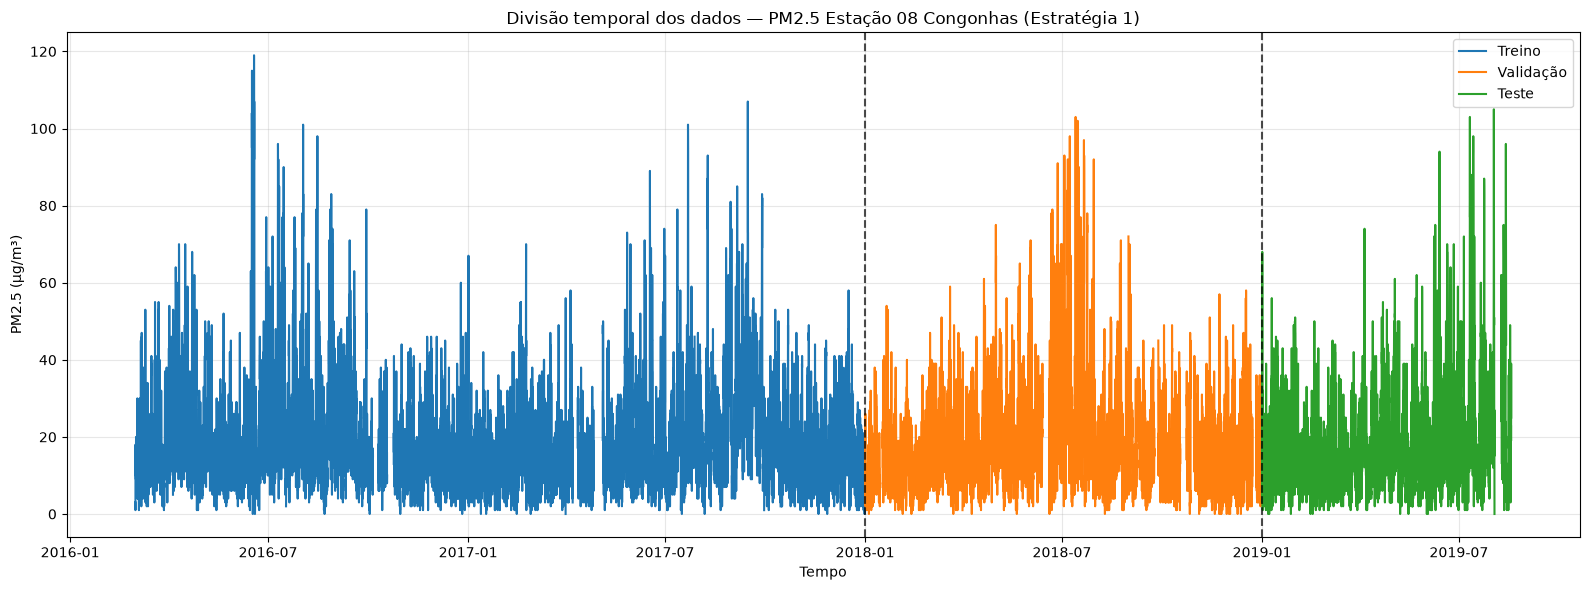

In [34]:
# Visualizar divisão temporal dos dados - Estratégia 1 como referência
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train_01["ds"], train_01["y"], label="Treino",    color="tab:blue")
ax.plot(val_01["ds"],   val_01["y"],   label="Validação", color="tab:orange")
ax.plot(test_01["ds"],  test_01["y"],  label="Teste",     color="tab:green")

ax.axvline(val_01["ds"].iloc[0],  color="black", linestyle="--", alpha=0.7)
ax.axvline(test_01["ds"].iloc[0], color="black", linestyle="--", alpha=0.7)

ax.set_title("Divisão temporal dos dados — PM2.5 Estação 08 Congonhas (Estratégia 1)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Tempo")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Modelo baseline Prophet (sem regressores)

In [44]:
def treinar_prophet_baseline(train, val):
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="additive"
    )

    modelo.fit(train[["ds", "y"]])

    future_val = val[["ds"]].copy()
    forecast_val = modelo.predict(future_val)

    y_pred = forecast_val["yhat"].values
    y_pred = np.clip(y_pred, 0, None)

    # Alinhar e remover NaN do y_true antes de avaliar
    mask = ~np.isnan(val["y"].values)
    y_true = val["y"].values[mask]
    y_pred = y_pred[mask]

    resultados = {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

    return modelo, forecast_val, y_pred, resultados

In [45]:
modelo_b01, forecast_b_val_01, y_pred_b_val_01, res_b_val_01 = treinar_prophet_baseline(train_01, val_01)
modelo_b02, forecast_b_val_02, y_pred_b_val_02, res_b_val_02 = treinar_prophet_baseline(train_02, val_02)
modelo_b03, forecast_b_val_03, y_pred_b_val_03, res_b_val_03 = treinar_prophet_baseline(train_03, val_03)

00:57:46 - cmdstanpy - INFO - Chain [1] start processing
00:57:50 - cmdstanpy - INFO - Chain [1] done processing
00:57:52 - cmdstanpy - INFO - Chain [1] start processing
00:57:57 - cmdstanpy - INFO - Chain [1] done processing
00:58:00 - cmdstanpy - INFO - Chain [1] start processing
00:58:04 - cmdstanpy - INFO - Chain [1] done processing


In [46]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Prophet Baseline", **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet Baseline", **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet Baseline", **res_b_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Prophet Baseline,14.086517,18.887016,-1.085761
1,Estratégia 2,Prophet Baseline,14.704963,19.487249,-1.221267
2,Estratégia 3,Prophet Baseline,14.360734,18.912971,-1.230903


## Adicionar Regressores ao modelo

In [47]:
REGRESSORES = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"
]

In [48]:
def treinar_prophet_regressores(train, val):
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="additive"
    )

    for reg in REGRESSORES:
        modelo.add_regressor(reg)

    modelo.fit(train[["ds", "y"] + REGRESSORES])

    future_val = val[["ds"] + REGRESSORES].copy()
    forecast_val = modelo.predict(future_val)

    y_pred = forecast_val["yhat"].values
    y_pred = np.clip(y_pred, 0, None)

    mask = ~np.isnan(val["y"].values)
    y_true = val["y"].values[mask]
    y_pred = y_pred[mask]

    resultados = {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

    return modelo, forecast_val, y_pred, resultados

In [49]:
modelo_r01, forecast_r_val_01, y_pred_r_val_01, res_r_val_01 = treinar_prophet_regressores(train_01, val_01)
modelo_r02, forecast_r_val_02, y_pred_r_val_02, res_r_val_02 = treinar_prophet_regressores(train_02, val_02)
modelo_r03, forecast_r_val_03, y_pred_r_val_03, res_r_val_03 = treinar_prophet_regressores(train_03, val_03)

01:00:58 - cmdstanpy - INFO - Chain [1] start processing
01:01:00 - cmdstanpy - INFO - Chain [1] done processing
01:01:03 - cmdstanpy - INFO - Chain [1] start processing
01:01:07 - cmdstanpy - INFO - Chain [1] done processing
01:01:10 - cmdstanpy - INFO - Chain [1] start processing
01:01:16 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Prophet + Regressores", **res_r_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + Regressores", **res_r_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + Regressores", **res_r_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Prophet + Regressores,8.435044,12.170632,0.133908
1,Estratégia 2,Prophet + Regressores,8.866514,13.180672,-0.016190
2,Estratégia 3,Prophet + Regressores,8.706148,12.881490,-0.034888


## Comparar Baseline vs Regressores

In [53]:
comparacao_val = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Prophet Baseline",       **res_b_val_01},
    {"estrategia": "Estratégia 1", "modelo": "Prophet + Regressores",  **res_r_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet Baseline",       **res_b_val_02},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + Regressores",  **res_r_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet Baseline",       **res_b_val_03},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + Regressores",  **res_r_val_03},
])

comparacao_val.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
1,Estratégia 1,Prophet + Regressores,8.435044,12.170632,0.133908
5,Estratégia 3,Prophet + Regressores,8.706148,12.881490,-0.034888
3,Estratégia 2,Prophet + Regressores,8.866514,13.180672,-0.016190
0,Estratégia 1,Prophet Baseline,14.086517,18.887016,-1.085761
4,Estratégia 3,Prophet Baseline,14.360734,18.912971,-1.230903
2,Estratégia 2,Prophet Baseline,14.704963,19.487249,-1.221267


## Ver os resultados no split de Teste

In [54]:
def avaliar_teste_prophet(modelo, test):
    future_test = test[["ds"] + REGRESSORES].copy()
    forecast_test = modelo.predict(future_test)

    y_pred = forecast_test["yhat"].values
    y_pred = np.clip(y_pred, 0, None)

    mask = ~np.isnan(test["y"].values)
    y_true = test["y"].values[mask]
    y_pred = y_pred[mask]

    resultados = {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

    return forecast_test, y_pred, resultados

In [56]:
forecast_test_r01, y_pred_test_r01, res_test_r01 = avaliar_teste_prophet(modelo_r01, test_01)
forecast_test_r02, y_pred_test_r02, res_test_r02 = avaliar_teste_prophet(modelo_r02, test_02)
forecast_test_r03, y_pred_test_r03, res_test_r03 = avaliar_teste_prophet(modelo_r03, test_03)

In [57]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "split": "Validação", **res_r_val_01},
    {"estrategia": "Estratégia 1", "split": "Teste",     **res_test_r01},
    {"estrategia": "Estratégia 2", "split": "Validação", **res_r_val_02},
    {"estrategia": "Estratégia 2", "split": "Teste",     **res_test_r02},
    {"estrategia": "Estratégia 3", "split": "Validação", **res_r_val_03},
    {"estrategia": "Estratégia 3", "split": "Teste",     **res_test_r03},
])

,estrategia,split,MAE,RMSE,R2
0,Estratégia 1,Validação,8.435044,12.170632,0.133908
1,Estratégia 1,Teste,8.237501,12.457640,0.082834
2,Estratégia 2,Validação,8.866514,13.180672,-0.016190
3,Estratégia 2,Teste,11.333498,15.963393,-0.508405
4,Estratégia 3,Validação,8.706148,12.881490,-0.034888
5,Estratégia 3,Teste,11.090455,15.637967,-0.476465


### Estratégia 1 é a mais consistente, MAE melhorou no teste, entretanto RMSE e R² pioraram um pouco.
### Enquanto as estratégias 2 e 3 colapsam no teste, aparentemente a imputação artificial no treino cria um modelo que não generaliza bem para dados reais.

## Conclusão: para o Prophet, a Estratégia 1 é a melhor configuração, sem interpolação, deixando o Prophet lidar com os gaps por si só, como ele foi projetado para fazer.

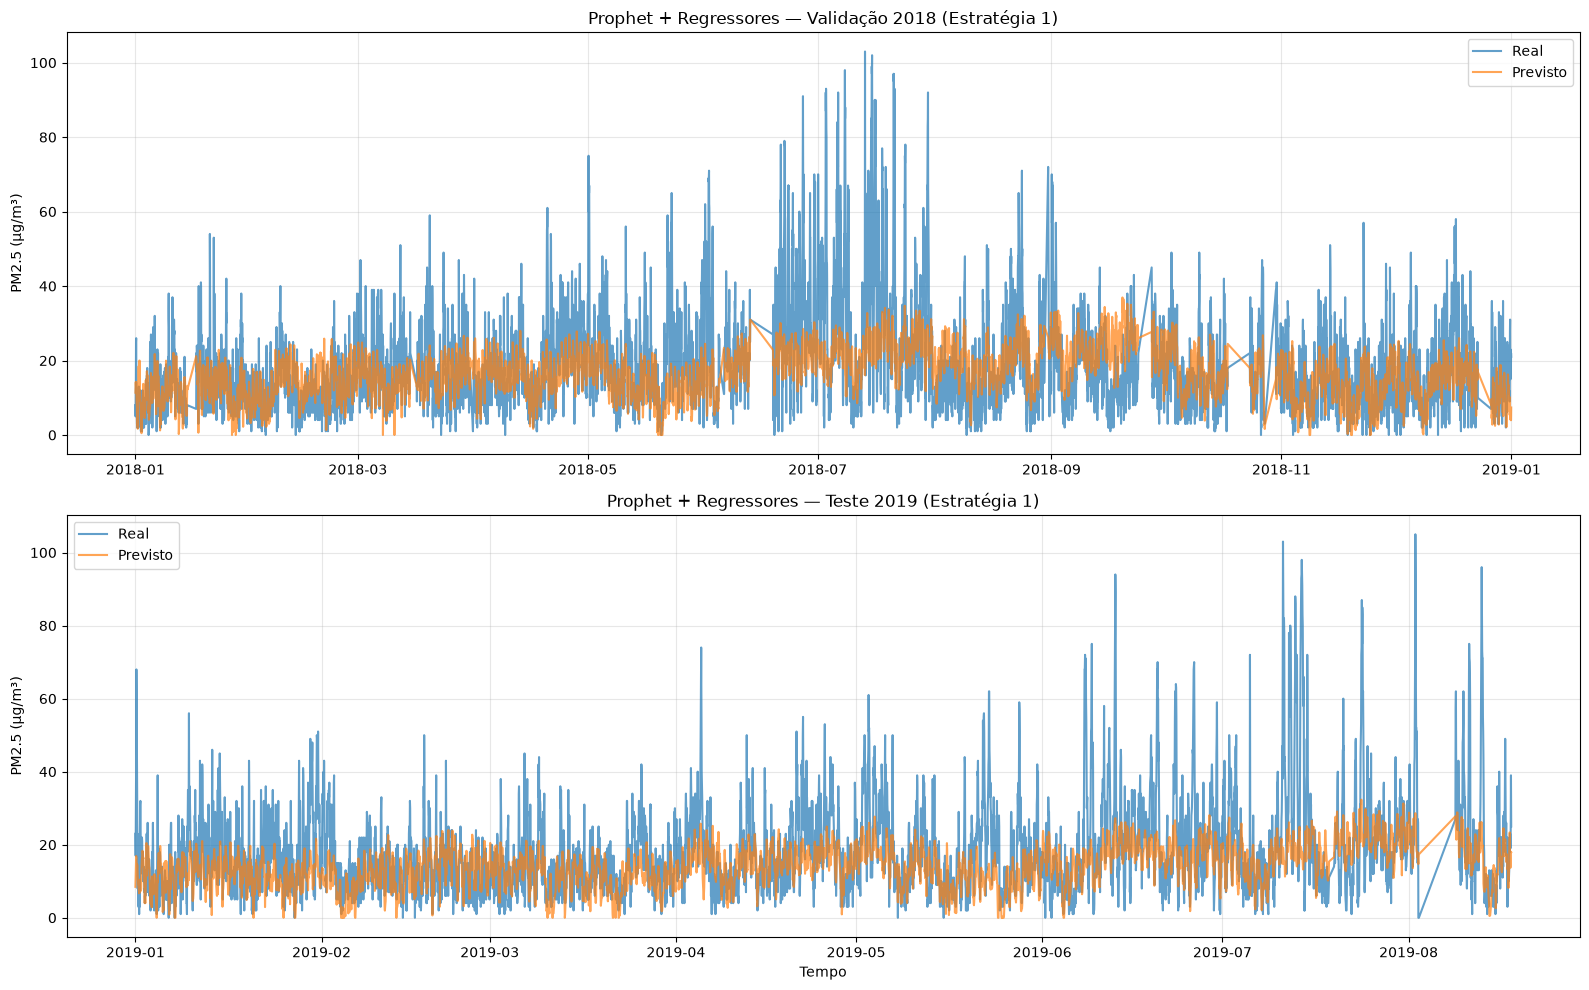

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Validação
mask_val = ~np.isnan(val_01["y"].values)
axes[0].plot(
    val_01["ds"].values[mask_val],
    val_01["y"].values[mask_val],
    label="Real", color="tab:blue", alpha=0.7
)
axes[0].plot(
    val_01["ds"].values[mask_val],
    y_pred_r_val_01,
    label="Previsto", color="tab:orange", alpha=0.7
)
axes[0].set_title("Prophet + Regressores — Validação 2018 (Estratégia 1)")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Teste
mask_test = ~np.isnan(test_01["y"].values)
axes[1].plot(
    test_01["ds"].values[mask_test],
    test_01["y"].values[mask_test],
    label="Real", color="tab:blue", alpha=0.7
)
axes[1].plot(
    test_01["ds"].values[mask_test],
    y_pred_test_r01,
    label="Previsto", color="tab:orange", alpha=0.7
)
axes[1].set_title("Prophet + Regressores — Teste 2019 (Estratégia 1)")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Tempo")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Os picos acontecem frequentemente no inverno(Junho-Agosto), o Prophet não consegue acompanhar esses picos.
### Entretanto o modelo funciona bem na base.

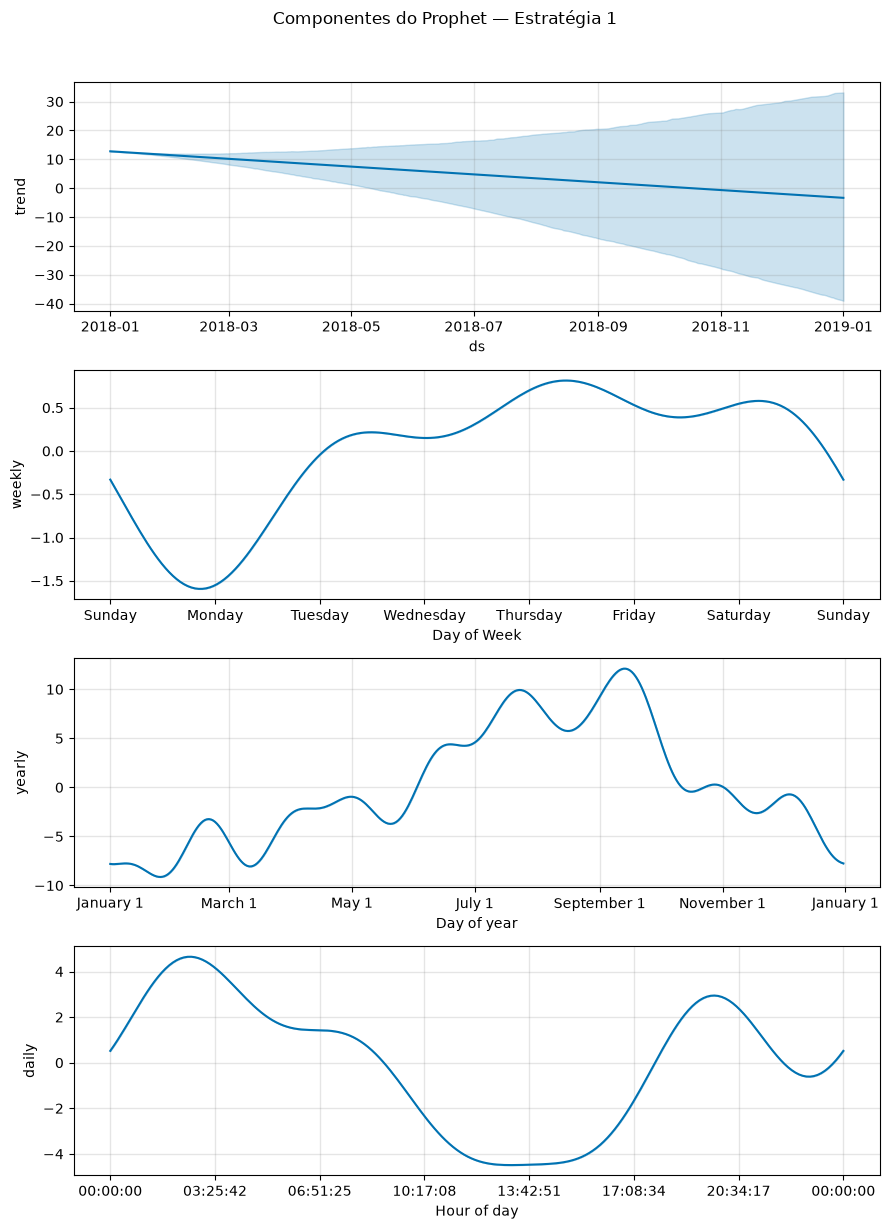

In [60]:
fig = modelo_r01.plot_components(forecast_b_val_01)
fig.suptitle("Componentes do Prophet — Estratégia 1", y=1.02)
plt.tight_layout()
plt.show()

### Trend: leve declínio ao longo de 2018, com incerteza crescendo bastante no segundo semestre. O modelo está cada vez menos confiante sobre a tendência, faz sentido porque os picos de inverno confundem a estimativa de tendência linear.

### Weekly: padrão muito coerente com o que se espera de poluição urbana, segunda-feira tem o vale mais profundo (menos tráfego logo após o fim de semana, ou efeito de limpeza noturna do domingo), e quinta-sexta são os picos. O domingo também cai. Isso é um sinal real de comportamento urbano capturado corretamente.

### Yearly: Modelo aprendeu a sazonalidade do pico do inverno

### Daily: dois picos, um por volta das 3-4h da madrugada e outro às 20h. O vale é ao meio-dia

## Vou adicionar uma feature 'is_winter' que anteriormente foi testado pela izabel no LightGBM + Dart.

In [61]:
def add_is_winter(df):
    df = df.copy()
    df["is_winter"] = df["ds"].dt.month.isin([6, 7, 8]).astype(int)
    return df

In [62]:
df_p01 = add_is_winter(df_p01)
df_p02 = add_is_winter(df_p02)
df_p03 = add_is_winter(df_p03)

In [63]:
# Refazer os splits com a nova feature
train_01, val_01, test_01 = split_temporal_prophet(df_p01)
train_02, val_02, test_02 = split_temporal_prophet(df_p02)
train_03, val_03, test_03 = split_temporal_prophet(df_p03)

In [64]:
print(df_p01[["ds", "y", "is_winter"]].head(10))
print(f"\nDistribuição is_winter: {df_p01['is_winter'].value_counts().to_dict()}")

                   ds     y  is_winter
0 2016-03-01 00:00:00   3.0          0
1 2016-03-01 01:00:00   1.0          0
2 2016-03-01 02:00:00  18.0          0
3 2016-03-01 03:00:00  17.0          0
4 2016-03-01 04:00:00  10.0          0
5 2016-03-01 05:00:00  14.0          0
6 2016-03-01 06:00:00  11.0          0
7 2016-03-01 07:00:00  13.0          0
8 2016-03-01 08:00:00  12.0          0
9 2016-03-01 09:00:00  14.0          0

Distribuição is_winter: {0: 21864, 1: 8499}


In [66]:
df_p01.isna().sum()

ds                         0
y                       1549
temperature_2m             0
relative_humidity_2m       0
precipitation              0
wind_speed_10m             0
is_winter                  0
dtype: int64

In [67]:
df_p02.isna().sum()

ds                         0
y                       1458
temperature_2m             0
relative_humidity_2m       0
precipitation              0
wind_speed_10m             0
is_winter                  0
dtype: int64

In [68]:
df_p03.isna().sum()

ds                      0
y                       0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
is_winter               0
dtype: int64

In [77]:
# Experimento 1: multiplicative com regressores - sem o is_winter
def treinar_prophet_multiplicative(train, val):
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="multiplicative"
    )

    for reg in REGRESSORES:
        modelo.add_regressor(reg)

    modelo.fit(train[["ds", "y"] + REGRESSORES])

    future_val = val[["ds"] + REGRESSORES].copy()
    forecast_val = modelo.predict(future_val)

    y_pred = np.clip(forecast_val["yhat"].values, 0, None)

    mask = ~np.isnan(val["y"].values)
    y_true = val["y"].values[mask]
    y_pred = y_pred[mask]

    resultados = {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

    return modelo, forecast_val, y_pred, resultados

In [70]:
modelo_m01, fc_m_val_01, yp_m_val_01, res_m_val_01 = treinar_prophet_multiplicative(train_01, val_01)
modelo_m02, fc_m_val_02, yp_m_val_02, res_m_val_02 = treinar_prophet_multiplicative(train_02, val_02)
modelo_m03, fc_m_val_03, yp_m_val_03, res_m_val_03 = treinar_prophet_multiplicative(train_03, val_03)

02:10:54 - cmdstanpy - INFO - Chain [1] start processing
02:10:58 - cmdstanpy - INFO - Chain [1] done processing
02:11:01 - cmdstanpy - INFO - Chain [1] start processing
02:11:07 - cmdstanpy - INFO - Chain [1] done processing
02:11:10 - cmdstanpy - INFO - Chain [1] start processing
02:11:17 - cmdstanpy - INFO - Chain [1] done processing


In [71]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Prophet Multiplicative", **res_m_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet Multiplicative", **res_m_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet Multiplicative", **res_m_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Prophet Multiplicative,17.535948,22.168662,-1.873538
1,Estratégia 2,Prophet Multiplicative,17.576469,22.187445,-1.879482
2,Estratégia 3,Prophet Multiplicative,17.320091,21.795138,-1.962650


In [72]:
REGRESSORES_V2 = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "is_winter"
]

In [73]:
def treinar_prophet_is_winter(train, val):
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="additive"
    )

    for reg in REGRESSORES_V2:
        modelo.add_regressor(reg)

    modelo.fit(train[["ds", "y"] + REGRESSORES_V2])

    future_val = val[["ds"] + REGRESSORES_V2].copy()
    forecast_val = modelo.predict(future_val)

    y_pred = np.clip(forecast_val["yhat"].values, 0, None)

    mask = ~np.isnan(val["y"].values)
    y_true = val["y"].values[mask]
    y_pred = y_pred[mask]

    resultados = {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    }

    return modelo, forecast_val, y_pred, resultados

In [74]:
modelo_w01, fc_w_val_01, yp_w_val_01, res_w_val_01 = treinar_prophet_is_winter(train_01, val_01)
modelo_w02, fc_w_val_02, yp_w_val_02, res_w_val_02 = treinar_prophet_is_winter(train_02, val_02)
modelo_w03, fc_w_val_03, yp_w_val_03, res_w_val_03 = treinar_prophet_is_winter(train_03, val_03)

02:17:33 - cmdstanpy - INFO - Chain [1] start processing
02:17:37 - cmdstanpy - INFO - Chain [1] done processing
02:17:40 - cmdstanpy - INFO - Chain [1] start processing
02:17:43 - cmdstanpy - INFO - Chain [1] done processing
02:17:46 - cmdstanpy - INFO - Chain [1] start processing
02:17:50 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Prophet + is_winter", **res_w_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + is_winter", **res_w_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + is_winter", **res_w_val_03},
])

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Prophet + is_winter,9.188836,13.629503,-0.086170
1,Estratégia 2,Prophet + is_winter,8.748157,12.988383,0.013244
2,Estratégia 3,Prophet + is_winter,8.717062,12.894628,-0.037000


In [76]:
comparacao_experimentos_val = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Prophet Baseline",        **res_b_val_01},
    {"estrategia": "Estratégia 1", "modelo": "Prophet + Regressores",   **res_r_val_01},
    {"estrategia": "Estratégia 1", "modelo": "Prophet Multiplicative",  **res_m_val_01},
    {"estrategia": "Estratégia 1", "modelo": "Prophet + is_winter",     **res_w_val_01},

    {"estrategia": "Estratégia 2", "modelo": "Prophet Baseline",        **res_b_val_02},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + Regressores",   **res_r_val_02},
    {"estrategia": "Estratégia 2", "modelo": "Prophet Multiplicative",  **res_m_val_02},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + is_winter",     **res_w_val_02},

    {"estrategia": "Estratégia 3", "modelo": "Prophet Baseline",        **res_b_val_03},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + Regressores",   **res_r_val_03},
    {"estrategia": "Estratégia 3", "modelo": "Prophet Multiplicative",  **res_m_val_03},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + is_winter",     **res_w_val_03},
])

comparacao_experimentos_val.sort_values("RMSE")

,estrategia,modelo,MAE,RMSE,R2
1,Estratégia 1,Prophet + Regressores,8.435044,12.170632,0.133908
9,Estratégia 3,Prophet + Regressores,8.706148,12.881490,-0.034888
11,Estratégia 3,Prophet + is_winter,8.717062,12.894628,-0.037000
7,Estratégia 2,Prophet + is_winter,8.748157,12.988383,0.013244
5,Estratégia 2,Prophet + Regressores,8.866514,13.180672,-0.016190
3,Estratégia 1,Prophet + is_winter,9.188836,13.629503,-0.086170
0,Estratégia 1,Prophet Baseline,14.086517,18.887016,-1.085761
8,Estratégia 3,Prophet Baseline,14.360734,18.912971,-1.230903
4,Estratégia 2,Prophet Baseline,14.704963,19.487249,-1.221267
10,Estratégia 3,Prophet Multiplicative,17.320091,21.795138,-1.962650


## Testar novos valores para os hiperparamentros que parecem ter dado mais resultado

In [81]:
changepoint_prior_scales = [0.001, 0.01, 0.1, 0.5]
seasonality_prior_scales  = [0.01, 0.1, 1.0, 10.0]
resultados_grid = []

In [84]:
for cps, sps in product(changepoint_prior_scales, seasonality_prior_scales):
    modelo_grid = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="additive",
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps
    )

    for reg in REGRESSORES:
        modelo_grid.add_regressor(reg)

    modelo_grid.fit(train_01[["ds", "y"] + REGRESSORES])

    future_val = val_01[["ds"] + REGRESSORES].copy()
    forecast_grid = modelo_grid.predict(future_val)

    y_pred = np.clip(forecast_grid["yhat"].values, 0, None)

    mask = ~np.isnan(val_01["y"].values)
    y_true = val_01["y"].values[mask]
    y_pred = y_pred[mask]

    resultados_grid.append({
        "changepoint_prior_scale": cps,
        "seasonality_prior_scale": sps,
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred)
    })

    print(f"cps={cps}, sps={sps} → RMSE={np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

02:49:26 - cmdstanpy - INFO - Chain [1] start processing
02:49:28 - cmdstanpy - INFO - Chain [1] done processing


cps=0.001, sps=0.01 → RMSE=11.8152


02:49:30 - cmdstanpy - INFO - Chain [1] start processing
02:49:31 - cmdstanpy - INFO - Chain [1] done processing


cps=0.001, sps=0.1 → RMSE=11.8175


02:49:34 - cmdstanpy - INFO - Chain [1] start processing
02:49:35 - cmdstanpy - INFO - Chain [1] done processing


...

cps=0.5, sps=0.1 → RMSE=16.6802


02:50:57 - cmdstanpy - INFO - Chain [1] start processing
02:51:06 - cmdstanpy - INFO - Chain [1] done processing


cps=0.5, sps=1.0 → RMSE=16.3260


02:51:08 - cmdstanpy - INFO - Chain [1] start processing
02:51:17 - cmdstanpy - INFO - Chain [1] done processing


cps=0.5, sps=10.0 → RMSE=15.8760


In [85]:
df_grid = pd.DataFrame(resultados_grid).sort_values("RMSE")
df_grid.head(10)

,changepoint_prior_scale,seasonality_prior_scale,MAE,RMSE,R2
0,0.001,0.01,8.526896,11.815198,0.183756
16,0.001,0.01,8.526896,11.815198,0.183756
19,0.001,10.00,8.506672,11.817112,0.183492
3,0.001,10.00,8.506672,11.817112,0.183492
1,0.001,0.10,8.521733,11.817531,0.183434
17,0.001,0.10,8.521733,11.817531,0.183434
18,0.001,1.00,8.525054,11.818388,0.183315
2,0.001,1.00,8.525054,11.818388,0.183315
6,0.010,1.00,9.193762,12.170189,0.133971
22,0.010,1.00,9.193762,12.170189,0.133971


### O melhores parâmetros: changepoint_prior_scale=0.001, seasonality_prior_scale=0.01. 

## Agora treinar o modelo final com esses parâmetros e avalia no teste.

In [86]:
modelo_tuned_01 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode="additive",
    changepoint_prior_scale=0.001,
    seasonality_prior_scale=0.01
)

for reg in REGRESSORES:
    modelo_tuned_01.add_regressor(reg)

modelo_tuned_01.fit(train_01[["ds", "y"] + REGRESSORES])

03:10:52 - cmdstanpy - INFO - Chain [1] start processing
03:10:53 - cmdstanpy - INFO - Chain [1] done processing


In [87]:
# Validação
future_val = val_01[["ds"] + REGRESSORES].copy()
forecast_tuned_val = modelo_tuned_01.predict(future_val)
y_pred_tuned_val = np.clip(forecast_tuned_val["yhat"].values, 0, None)
mask_val = ~np.isnan(val_01["y"].values)
res_tuned_val = {
    "MAE":  mean_absolute_error(val_01["y"].values[mask_val], y_pred_tuned_val[mask_val]),
    "RMSE": np.sqrt(mean_squared_error(val_01["y"].values[mask_val], y_pred_tuned_val[mask_val])),
    "R2":   r2_score(val_01["y"].values[mask_val], y_pred_tuned_val[mask_val])
}

In [88]:
# Teste
future_test = test_01[["ds"] + REGRESSORES].copy()
forecast_tuned_test = modelo_tuned_01.predict(future_test)
y_pred_tuned_test = np.clip(forecast_tuned_test["yhat"].values, 0, None)
mask_test = ~np.isnan(test_01["y"].values)
res_tuned_test = {
    "MAE":  mean_absolute_error(test_01["y"].values[mask_test], y_pred_tuned_test[mask_test]),
    "RMSE": np.sqrt(mean_squared_error(test_01["y"].values[mask_test], y_pred_tuned_test[mask_test])),
    "R2":   r2_score(test_01["y"].values[mask_test], y_pred_tuned_test[mask_test])
}

In [89]:
pd.DataFrame([
    {"modelo": "Prophet + Regressores (default)", "split": "Validação", **res_r_val_01},
    {"modelo": "Prophet + Regressores (default)", "split": "Teste",     **res_test_r01},
    {"modelo": "Prophet Tuned (cps=0.001)",        "split": "Validação", **res_tuned_val},
    {"modelo": "Prophet Tuned (cps=0.001)",        "split": "Teste",     **res_tuned_test},
])

,modelo,split,MAE,RMSE,R2
0,Prophet + Regressores (default),Validação,8.435044,12.170632,0.133908
1,Prophet + Regressores (default),Teste,8.237501,12.457640,0.082834
2,Prophet Tuned (cps=0.001),Validação,8.526896,11.815198,0.183756
3,Prophet Tuned (cps=0.001),Teste,8.673104,11.834817,0.172249


In [93]:
df_cv = cross_validation(
    modelo_tuned_01,
    initial="500 days",
    period="30 days",
    horizon="24 hours",
    parallel="processes"
)

df_perf = performance_metrics(df_cv)
print(df_perf.columns.tolist())
df_perf[["horizon", "mae", "rmse"]].head(24)

03:24:36 - cmdstanpy - INFO - Chain [1] start processing
03:24:37 - cmdstanpy - INFO - Chain [1] start processing
03:24:37 - cmdstanpy - INFO - Chain [1] start processing
03:24:38 - cmdstanpy - INFO - Chain [1] start processing
03:24:38 - cmdstanpy - INFO - Chain [1] start processing
03:24:38 - cmdstanpy - INFO - Chain [1] start processing
03:24:38 - cmdstanpy - INFO - Chain [1] done processing
03:24:39 - cmdstanpy - INFO - Chain [1] done processing
03:24:39 - cmdstanpy - INFO - Chain [1] done processing
03:24:39 - cmdstanpy - INFO - Chain [1] done processing
03:24:40 - cmdstanpy - INFO - Chain [1] done processing


['horizon', 'mse', 'rmse', 'mae', 'mdape', 'smape', 'coverage']


03:24:40 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mae,rmse
0,0 days 03:00:00,6.357493,7.702898
1,0 days 04:00:00,5.480468,6.819945
2,0 days 05:00:00,4.339906,5.817100
3,0 days 06:00:00,4.341774,6.040767
4,0 days 07:00:00,4.474783,5.846982
5,0 days 08:00:00,5.155385,6.652029
6,0 days 09:00:00,5.524566,7.215299
7,0 days 10:00:00,4.806367,6.453067
8,0 days 11:00:00,4.338844,5.726567
9,0 days 12:00:00,4.059638,5.422620


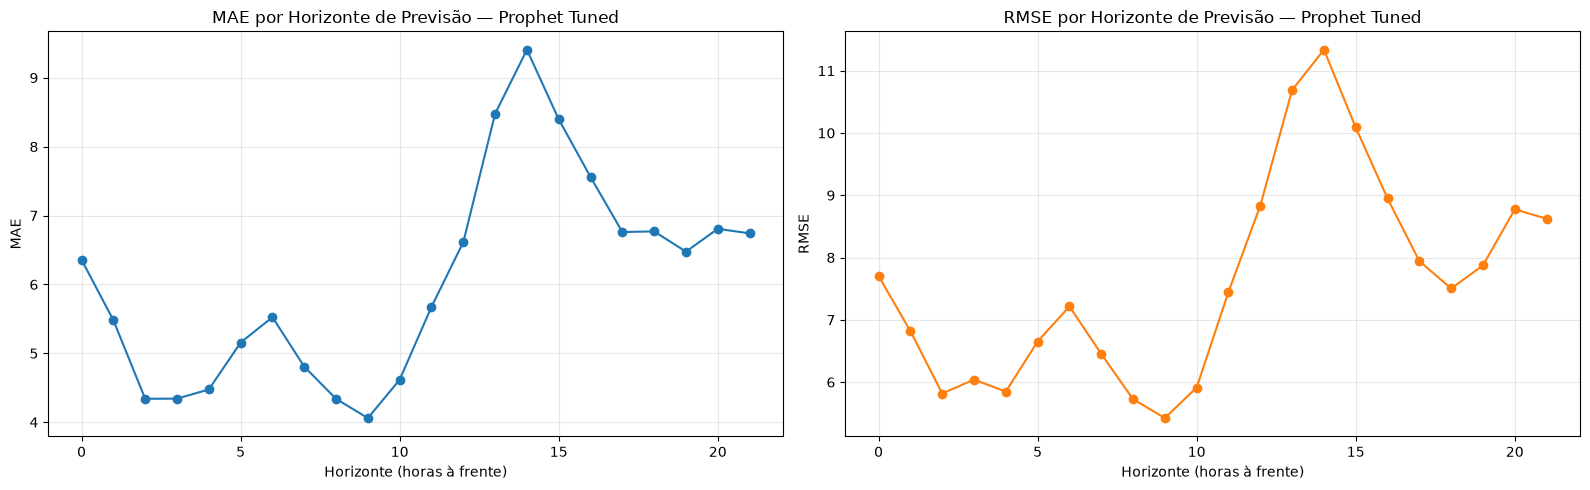

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hours = list(range(len(df_perf)))

axes[0].plot(hours, df_perf["mae"].values,  marker="o", color="tab:blue")
axes[0].set_title("MAE por Horizonte de Previsão — Prophet Tuned")
axes[0].set_xlabel("Horizonte (horas à frente)")
axes[0].set_ylabel("MAE")
axes[0].grid(alpha=0.3)

axes[1].plot(hours, df_perf["rmse"].values, marker="o", color="tab:orange")
axes[1].set_title("RMSE por Horizonte de Previsão — Prophet Tuned")
axes[1].set_xlabel("Horizonte (horas à frente)")
axes[1].set_ylabel("RMSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [95]:
comparacao_final = pd.DataFrame([
    # Baseline
    {"estrategia": "Estratégia 1", "modelo": "Prophet Baseline",              "split": "Validação", **res_b_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet Baseline",              "split": "Validação", **res_b_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet Baseline",              "split": "Validação", **res_b_val_03},

    # Regressores (default)
    {"estrategia": "Estratégia 1", "modelo": "Prophet + Regressores",         "split": "Validação", **res_r_val_01},
    {"estrategia": "Estratégia 1", "modelo": "Prophet + Regressores",         "split": "Teste",     **res_test_r01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + Regressores",         "split": "Validação", **res_r_val_02},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + Regressores",         "split": "Teste",     **res_test_r02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + Regressores",         "split": "Validação", **res_r_val_03},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + Regressores",         "split": "Teste",     **res_test_r03},

    # is_winter
    {"estrategia": "Estratégia 1", "modelo": "Prophet + is_winter",           "split": "Validação", **res_w_val_01},
    {"estrategia": "Estratégia 2", "modelo": "Prophet + is_winter",           "split": "Validação", **res_w_val_02},
    {"estrategia": "Estratégia 3", "modelo": "Prophet + is_winter",           "split": "Validação", **res_w_val_03},

    # Tuned
    {"estrategia": "Estratégia 1", "modelo": "Prophet Tuned (cps=0.001)",     "split": "Validação", **res_tuned_val},
    {"estrategia": "Estratégia 1", "modelo": "Prophet Tuned (cps=0.001)",     "split": "Teste",     **res_tuned_test},
])

comparacao_final.sort_values(["split", "RMSE"])

,estrategia,modelo,split,MAE,RMSE,R2
13,Estratégia 1,Prophet Tuned (cps=0.001),Teste,8.673104,11.834817,0.172249
4,Estratégia 1,Prophet + Regressores,Teste,8.237501,12.457640,0.082834
8,Estratégia 3,Prophet + Regressores,Teste,11.090455,15.637967,-0.476465
6,Estratégia 2,Prophet + Regressores,Teste,11.333498,15.963393,-0.508405
12,Estratégia 1,Prophet Tuned (cps=0.001),Validação,8.526896,11.815198,0.183756
3,Estratégia 1,Prophet + Regressores,Validação,8.435044,12.170632,0.133908
7,Estratégia 3,Prophet + Regressores,Validação,8.706148,12.881490,-0.034888
11,Estratégia 3,Prophet + is_winter,Validação,8.717062,12.894628,-0.037000
10,Estratégia 2,Prophet + is_winter,Validação,8.748157,12.988383,0.013244
5,Estratégia 2,Prophet + Regressores,Validação,8.866514,13.180672,-0.016190
